In [24]:
import pandas as pd
import numpy as np

from rdkit.Chem import Draw, MolFromSmiles, ReplaceSubstructs, RemoveAllHs, FragmentOnBRICSBonds, GetMolFrags, MolToSmiles
from IPython.display import SVG

# Load Data

In [25]:
df_expl = pd.read_pickle('rf_classification_mutagenicity/df_explanation.pkl')
split = 0
df_expl = df_expl.loc[df_expl.split == split]
df_expl.head()

,dataset,split,smiles,y_true,y_pred,y_pred_proba,fragExplainer_result,fragExplainer_expected_value,fragExplainer_expected_value_logits,shap_result,shape_expected_value,frag_to_atom_ids,atom_id_to_bits
0,mutagenicity,0,O=[N+]([O-])c1ccc2ccc3ccc([N+](=O)[O-])c4c5ccc...,1,1,0.995,{0: 7.735441472126716},0.08,-2.442337,"[0.0, 0.003672657400859738, -4.093517156434245...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,...","{5: [203, 1750, 1873], 7: [203, 1750, 1873], 8..."
1,mutagenicity,0,CCN(CC(O)C1=CC(=O)C(=[N+]=[N-])C=C1)N=O,1,1,0.885,{0: 4.482983573353697},0.08,-2.442337,"[0.0, -0.004228411446422236, -6.82536196768523...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,...","{4: [1, 165, 1362], 1: [80, 932, 1039], 3: [80..."
2,mutagenicity,0,C#CC1(OC(=O)CCCCCC)CCC2C3CCC4=CC(=O)CCC4C3CCC21C,0,0,0.030,"{0: -0.6003725791786283, 1: -0.019151843724327...",0.08,-2.442337,"[0.0, -0.0007230396759015667, -5.0386004301685...",0.56035,"{0: [0, 1, 2, 12, 13, 14, 15, 16, 17, 18, 19, ...","{18: [57, 292, 1380], 6: [80, 1399, 1564], 7: ..."
3,mutagenicity,0,OC1C=Cc2c(ccc3c(Br)c4ccccc4cc23)C1O,1,1,0.740,{0: 3.488301682767639},0.08,-2.442337,"[0.0, 0.004915755669061008, 5.9491886167961635...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,...","{1: [109, 1019, 1557], 19: [127, 164, 1019], 1..."
4,mutagenicity,0,C[C@@H](O)CCC(=O)c1ccoc1,0,0,0.110,"{0: -0.41516402206040637, 1: 0.7667665147959731}",0.08,-2.442337,"[0.0, -0.014181808895611, -9.999097916079336e-...",0.56035,"{0: [0, 1, 2, 3, 4, 5, 6], 1: [7, 8, 9, 10, 11]}","{1: [1, 913, 1898], 3: [80, 739, 876], 4: [80,..."


# Simple Visualization

In [26]:

def visualize_contributions(smiles, contributions, scale=0.5):
    chargeRadii = {}
    chargeColors = {}
    highlightAtoms = []
    for i,chg in enumerate(contributions):
        # quantize and scale the charge so that we can use it to scale the highlight radii
        #chg = (10*chg//1)/10
        if abs(chg)>1e-4:
            chargeRadii[i] = abs(chg) * scale
            highlightAtoms.append(i)
            if chg>0:
                chargeColors[i] = (1,.5,.5)
            else:
                chargeColors[i] = (.5,.5,1)

    d2d = Draw.MolDraw2DSVG(550,350)
    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    # we need to set the highlights to be circles or we'll end up with ovals
    # that fit around the atomic symbol
    dopts.atomHighlightsAreCircles = True

    # we need to provide highlightBonds=[] here to avoid having the bonds between highlighted atoms highlighted:
    d2d.DrawMolecule(MolFromSmiles(smiles),
                     highlightAtoms=highlightAtoms,
                     highlightAtomColors=chargeColors,
                     highlightAtomRadii=chargeRadii,
                     highlightBonds=[])
    d2d.FinishDrawing()
    return SVG(d2d.GetDrawingText())

In [27]:
def get_frag_contributions_from_result_dict(smiles, results_dict, frag_to_atom_ids):
    contributions = np.zeros(MolFromSmiles(smiles).GetNumAtoms())
    for frag_id in range(len(results_dict.keys())):
        for atom_id in frag_to_atom_ids[frag_id]:
            contributions[atom_id] = results_dict[frag_id]
    return contributions

In [28]:
# only consider true toxic ones
df_tmp = df_expl.loc[(df_expl.y_true == 1) & (df_expl.y_pred == 1)]
df_tmp.shape

(680, 13)

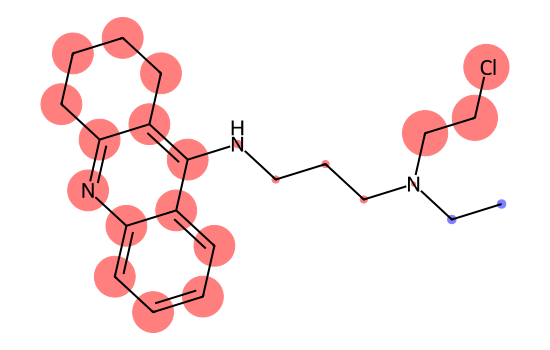

In [29]:
index = 5

# extract data from row
row = df_tmp.iloc[index]

smiles = row.smiles
y_pred_proba = row.y_pred_proba
explainer_result = row.fragExplainer_result
expected_value_logits = row.fragExplainer_expected_value_logits
frag_to_atom_ids = row.frag_to_atom_ids

contributions = get_frag_contributions_from_result_dict(smiles=row.smiles,
                                                        results_dict=row.fragExplainer_result,
                                                        frag_to_atom_ids=row.frag_to_atom_ids)

visualize_contributions(smiles=row.smiles,
                        contributions=contributions,
                        scale=0.3)

# Identify substituent with strongest contribution

In [34]:
def remove_isotope_information_for_dummy_atoms(m):
    for at in m.GetAtoms():
        if at.GetSymbol() == '*':
            at.SetIsotope(0)
    return m

def remove_dummy_atoms(m):
    dummy = MolFromSmiles('*')
    m_cleaned = ReplaceSubstructs(m, dummy, MolFromSmiles('[H]'), replaceAll=True)[0]
    return RemoveAllHs(m_cleaned, sanitize=True)

def get_BRICS_fragments_as_SMILES(smiles, remove_dummies=False):
    mol = MolFromSmiles(smiles)
    frag_ = FragmentOnBRICSBonds(mol)
    frags = GetMolFrags(frag_,
                        asMols=True)
    frags_cleaned = [remove_isotope_information_for_dummy_atoms(m) for m in frags]
    if remove_dummies:
        frags_cleaned = [remove_dummy_atoms(m) for m in frags_cleaned] 
    return [MolToSmiles(m) for m in frags_cleaned]

In [42]:
frag_smiles = get_BRICS_fragments_as_SMILES(row.smiles)
smiles_to_contrib = {k:v for k, v in zip(frag_smiles, row.fragExplainer_result.values())}

In [45]:
# only consider fragments with one substituent atm and with positive contributions
# we want to replace these with less toxic substituents
frags_to_consider = {k: v for k, v in smiles_to_contrib.items() if (v > 0.0) & (k.count('*') == 1)}

In [66]:
# https://patwalters.github.io/practicalcheminformatics/jupyter/chembl/2021/07/05/replace-rgroups.html

In [46]:
frags_to_consider

{'*CCCl': np.float64(2.171014688774231),
 '*c1c2c(nc3ccccc13)CCCC2': np.float64(1.9598465226786135)}

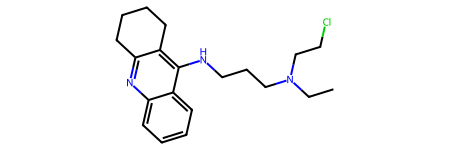

In [47]:
sm = row.smiles
base_mol = MolFromSmiles(sm)
base_mol

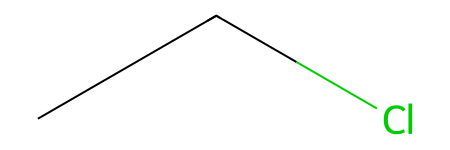

In [62]:
subs_sm = 'CCCl'#list(frags_to_consider.keys())[0]
subs_mol = MolFromSmiles(subs_sm)
subs_mol

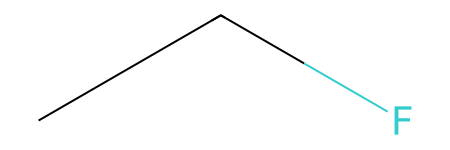

In [63]:
repr_sm = 'CCF'
repr_mol = MolFromSmiles(repr_sm)
repr_mol

In [64]:
from rdkit.Chem import ReplaceSubstructs

prods = ReplaceSubstructs(base_mol, subs_mol, repr_mol)

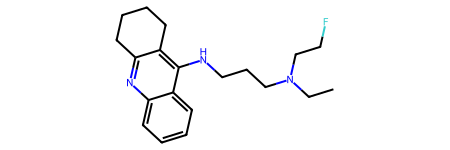

In [65]:
prods[0]